In [1]:

# ===== 1. 配置 =====

from pathlib import Path
import sys
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr

from scMM.file.data import CyESIData
from scMM.util.normalize import normalize

DATA_DIR = Path(r"/home/zby/scMM/data/algea_results/deisotope/1mM")
OUTPUT_DIR = Path(r"/home/zby/scMM/data/algea_results/res/1mM")
if str(OUTPUT_DIR) == "<OUTPUT_DIR>":
    OUTPUT_DIR = Path("./normalization_consistency_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- 时间字段 ----
# 请设置为 CyESIData 中实际保存连续采集时间的字段，例如：
# "time", "acquisition_time", "rt" 等。
TIME_KEY = "time"

# ---- 仅比较这四种状态 ----
METHODS = {
    "raw": None,
    "total": {"method": "total", "kwargs": {"scale": 1.0}},
    "pqn": {"method": "pqn", "kwargs": {"reference": "median"}},
    "quantile": {"method": "quantile", "kwargs": {}},
}

# ---- 高检出率代谢物 ----
MIN_DETECTION_FRACTION = 0.50

# 相关矩阵分析也使用相同的高检出率特征，避免 dropout 主导相关结构
CORR_MIN_DETECTION_FRACTION = 0.50

# 时间趋势窗口：
# 若时间单位为小时，可直接设置 WINDOW_WIDTH_H / STEP_H。
# 如果数据时间不是小时，请按实际单位修改。
WINDOW_WIDTH = 0.50
STEP_SIZE = 0.10

# 每个窗口至少需要多少细胞
MIN_CELLS_PER_WINDOW = 50

# 趋势中心统计量：median 对单细胞 MS 更稳健
TREND_STATISTIC = "median"   # "median" or "mean"

# 相关性
CORR_METHOD = "pearson"

# 最多展示多少个代表性代谢物的趋势图
N_TREND_EXAMPLES = 12

# 如有希望优先展示的 feature/mz/annotation，可填在这里
PREFERRED_FEATURES = [
    # "Chlorophyll a",
    # "Chlorophyll b",
]


/home/zby/miniconda3/envs/scMM/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ===== 2. 读取 CyESIData，并读取 peak_meta 中的时间 =====

obj = CyESIData(str(DATA_DIR))

# cell × feature intensity matrix
X_df = obj.data.copy()
X_df = X_df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

print("Data shape:", X_df.shape)
display(X_df.iloc[:5, :8])

# --------------------------------------------------
# scMM 中 cell/event-level metadata 保存在 peak_meta
# 连续时间字段为 peak_meta["time"]
# --------------------------------------------------

if not hasattr(obj, "peak_meta"):
    raise AttributeError(
        "CyESIData object does not contain 'peak_meta'. "
        "Please check whether the dataset was generated with the current scMM pipeline."
    )

peak_meta = obj.peak_meta.copy()

if "time" not in peak_meta.columns:
    raise KeyError(
        "'time' is not present in obj.peak_meta. "
        f"Available columns: {list(peak_meta.columns)}"
    )

# 确保 metadata 与强度矩阵逐行对应
if len(peak_meta) != len(X_df):
    raise ValueError(
        f"Row mismatch between data and peak_meta: "
        f"data={len(X_df)}, peak_meta={len(peak_meta)}"
    )

# scMM 已经生成好的连续时间参数
time = pd.to_numeric(
    peak_meta["time"],
    errors="coerce"
).to_numpy(dtype=float)

# 原始矩阵
X_raw_all = X_df.to_numpy(dtype=float)
feature_names_all = X_df.columns.astype(str).to_numpy()

# --------------------------------------------------
# 统一有效细胞集合
# 所有 normalization 必须使用完全相同的 cells
# --------------------------------------------------

valid_cells = (
    np.isfinite(time)
    & np.isfinite(X_raw_all).all(axis=1)
    & (np.sum(X_raw_all, axis=1) > 0)
    & (np.max(X_raw_all, axis=1) > 0)
)

X_raw_all = X_raw_all[valid_cells]
time = time[valid_cells]
peak_meta = peak_meta.loc[valid_cells].reset_index(drop=True)

print(f"Cells retained: {len(time)} / {len(valid_cells)}")
print(
    f"Normalized acquisition time range: "
    f"{np.nanmin(time):.4f} - {np.nanmax(time):.4f}"
)

display(peak_meta.head())

Data shape: (18969, 994)


,101.0090578,103.0072935,103.0760572,103.280608,103.5024723,103.5044779,103.6160587,103.9787682
cell_0,0.00000,0.0,9324.151367,0.0,0.000000,0.000000,0.00000,0.0
cell_1,0.00000,0.0,0.000000,0.0,4512.102051,0.000000,0.00000,0.0
cell_2,0.00000,0.0,0.000000,0.0,5323.310059,15469.053710,10750.58789,0.0
cell_3,0.00000,0.0,0.000000,0.0,0.000000,0.000000,0.00000,0.0
cell_4,28817.87695,0.0,10180.285160,0.0,0.000000,5980.356934,0.00000,0.0


Cells retained: 18969 / 18969
Normalized acquisition time range: 0.0000 - 1.0000


,rt,time
0,1.417343,0.000032
1,2.393224,0.000055
2,2.950842,0.000067
3,6.854360,0.000157
4,8.527227,0.000195


In [4]:

# ===== 3. 根据 raw 数据定义统一的高检出率代谢物集合 =====

detection_fraction_all = (X_raw_all > 0).mean(axis=0)
variance_all = np.var(X_raw_all, axis=0)

feature_mask = (
    (detection_fraction_all > MIN_DETECTION_FRACTION)
    & np.isfinite(variance_all)
    & (variance_all > 0)
)

X_raw = X_raw_all[:, feature_mask]
feature_names = feature_names_all[feature_mask]
detection_fraction = detection_fraction_all[feature_mask]

feature_qc = pd.DataFrame({
    "feature": feature_names,
    "detection_fraction": detection_fraction,
}).sort_values("detection_fraction", ascending=False)

print(f"Features with detection fraction > {MIN_DETECTION_FRACTION:.0%}: {len(feature_names)}")
display(feature_qc.head(20))


Features with detection fraction > 50%: 223


,feature,detection_fraction
139,756.5759797,1.000000
144,760.6072863,1.000000
140,757.5801869,1.000000
120,734.5919668,1.000000
121,736.6043594,1.000000
119,732.5770966,1.000000
102,706.5608946,1.000000
101,704.5458686,0.999947
142,759.5953865,0.999947
117,730.5607737,0.999895


In [5]:

# ===== 4. 使用 scMM 原生 normalize() 生成四种矩阵 =====

def apply_scmm_normalization(X, spec):
    if spec is None:
        return np.asarray(X, dtype=float).copy()
    return np.asarray(
        normalize(
            X,
            method=spec["method"],
            norm_kwargs=spec.get("kwargs", {}),
        ),
        dtype=float,
    )

normalized = {}

for name, spec in METHODS.items():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        Xn = apply_scmm_normalization(X_raw, spec)

    if not np.isfinite(Xn).all():
        raise ValueError(f"{name} normalization 产生非有限值，请检查输入和参数。")

    normalized[name] = Xn
    print(
        f"{name:>9s}: shape={Xn.shape}, "
        f"range=({np.min(Xn):.4g}, {np.max(Xn):.4g})"
    )


      raw: shape=(18969, 223), range=(0, 7.533e+07)
    total: shape=(18969, 223), range=(0, 0.3647)
      pqn: shape=(18969, 223), range=(0, 9.518e+08)
 quantile: shape=(18969, 223), range=(3929, 2.551e+06)



## Part I. 代谢物相关结构的一致性

对于每种归一化方法，均以单细胞作为独立观测，计算高检出率代谢物之间的相关系数：

\[
r_{jk}=\mathrm{cor}(X_{\cdot j},X_{\cdot k})
\]

随后将相关矩阵上三角展开为同一组 metabolite pairs，比较不同归一化方法下这些 \(r_{jk}\) 的一致性。


In [6]:

# ===== 5. 相关矩阵与 matrix-level consistency =====

def correlation_matrix(X, method="pearson"):
    df = pd.DataFrame(X, columns=feature_names)
    return df.corr(method=method)

def upper_triangle_vector(mat):
    arr = np.asarray(mat, dtype=float)
    iu = np.triu_indices_from(arr, k=1)
    return arr[iu]

corr_mats = {
    name: correlation_matrix(Xn, CORR_METHOD)
    for name, Xn in normalized.items()
}

corr_vectors = {
    name: upper_triangle_vector(mat)
    for name, mat in corr_mats.items()
}

method_names = list(METHODS)
sim_pearson = pd.DataFrame(np.eye(len(method_names)), index=method_names, columns=method_names)
sim_spearman = sim_pearson.copy()

for i, m1 in enumerate(method_names):
    for j, m2 in enumerate(method_names):
        if i >= j:
            continue
        a = corr_vectors[m1]
        b = corr_vectors[m2]
        mask = np.isfinite(a) & np.isfinite(b)
        sim_pearson.loc[m1, m2] = sim_pearson.loc[m2, m1] = pearsonr(a[mask], b[mask]).statistic
        sim_spearman.loc[m1, m2] = sim_spearman.loc[m2, m1] = spearmanr(a[mask], b[mask]).statistic

print("Pearson similarity between vectorized correlation matrices")
display(sim_pearson.round(4))

print("Spearman similarity between vectorized correlation matrices")
display(sim_spearman.round(4))


Pearson similarity between vectorized correlation matrices


,raw,total,pqn,quantile
raw,1.0000,0.5102,0.4956,0.9957
total,0.5102,1.0000,0.2770,0.5007
pqn,0.4956,0.2770,1.0000,0.5052
quantile,0.9957,0.5007,0.5052,1.0000


Spearman similarity between vectorized correlation matrices


,raw,total,pqn,quantile
raw,1.0000,0.4689,0.4899,0.9953
total,0.4689,1.0000,0.2622,0.4587
pqn,0.4899,0.2622,1.0000,0.4990
quantile,0.9953,0.4587,0.4990,1.0000


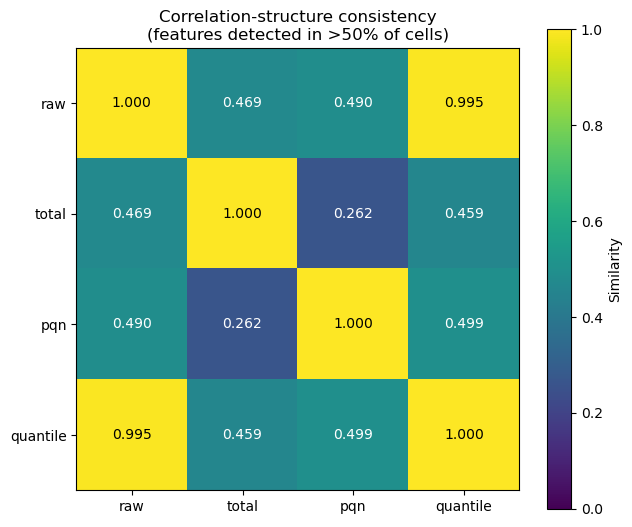

In [7]:

# ===== 6. 绘制 correlation-structure consistency heatmap =====

def plot_similarity(sim, title):
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(sim.to_numpy(), vmin=0, vmax=1, cmap="viridis")

    ax.set_xticks(np.arange(len(sim.columns)))
    ax.set_yticks(np.arange(len(sim.index)))
    ax.set_xticklabels(sim.columns)
    ax.set_yticklabels(sim.index)

    for i in range(sim.shape[0]):
        for j in range(sim.shape[1]):
            v = sim.iloc[i, j]
            ax.text(
                j, i, f"{v:.3f}",
                ha="center", va="center",
                color="white" if v < 0.6 else "black",
            )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Similarity")
    ax.set_title(title)
    fig.tight_layout()
    return fig, ax

plot_similarity(
    sim_spearman,
    f"Correlation-structure consistency\n(features detected in >{MIN_DETECTION_FRACTION:.0%} of cells)",
)
plt.show()


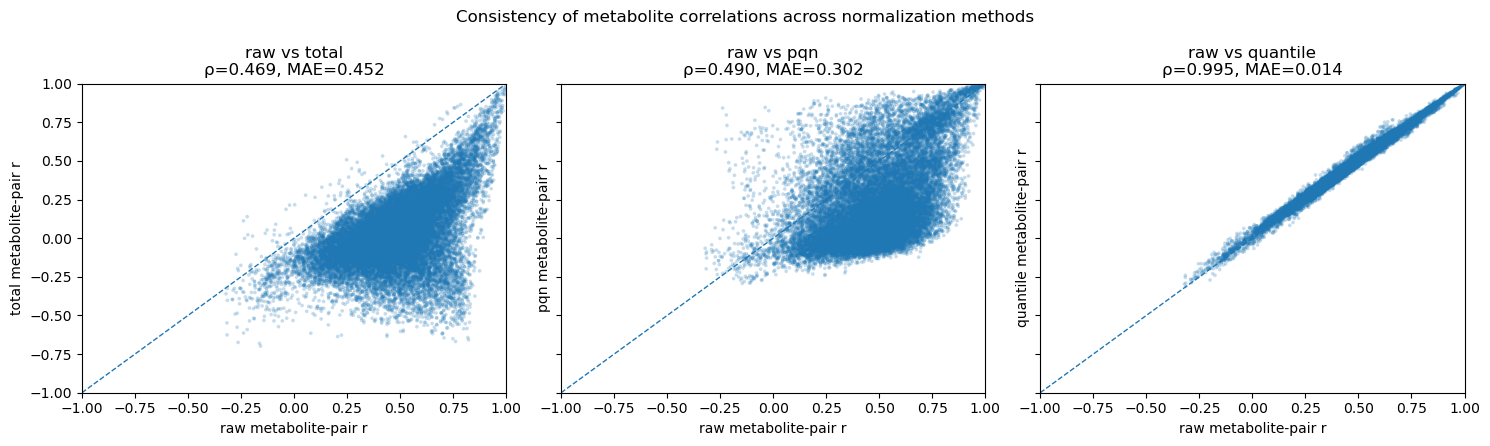

In [8]:

# ===== 7. raw vs normalized：metabolite-pair correlation scatter =====

reference = "raw"
others = ["total", "pqn", "quantile"]
ref_v = corr_vectors[reference]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)

for ax, method in zip(axes, others):
    v = corr_vectors[method]
    mask = np.isfinite(ref_v) & np.isfinite(v)
    x = ref_v[mask]
    y = v[mask]

    rho = spearmanr(x, y).statistic
    mae = np.mean(np.abs(x - y))

    ax.scatter(x, y, s=7, alpha=0.25, edgecolors="none", rasterized=True)
    ax.plot([-1, 1], [-1, 1], "--", lw=1)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_title(f"raw vs {method}\nρ={rho:.3f}, MAE={mae:.3f}")
    ax.set_xlabel("raw metabolite-pair r")
    ax.set_ylabel(f"{method} metabolite-pair r")

fig.suptitle("Consistency of metabolite correlations across normalization methods")
fig.tight_layout()
plt.show()



## Part II. 高检出率代谢物的时间趋势一致性

只使用在 **raw 数据中检出率 >50%** 的代谢物。

对每个代谢物 \(j\) 和每个时间滑动窗口 \(t\)，计算窗口内单细胞强度的中心统计量：

\[
T_j(t)=\mathrm{median}\{X_{ij}: i\in W_t\}
\]

然后分别得到 raw、total、PQN、quantile 下的时间趋势。

由于不同归一化方法的绝对尺度不可直接比较，趋势一致性主要比较**形状**而不是绝对强度。因此，每条代谢物趋势在各自方法内进一步进行 z-score：

\[
Z_j(t)=\frac{T_j(t)-\overline{T_j}}{\mathrm{SD}(T_j)}
\]

最后比较不同 normalization 下同一代谢物的 z-scored trend correlation。


In [9]:

# ===== 8. 生成统一的滑动时间窗口 =====

def make_time_windows(time, width, step, min_cells=50):
    start = np.nanmin(time)
    end = np.nanmax(time)

    centers = []
    indices = []

    left = start
    while left + width <= end + 1e-12:
        right = left + width
        idx = np.where((time >= left) & (time < right))[0]
        if len(idx) >= min_cells:
            centers.append((left + right) / 2)
            indices.append(idx)
        left += step

    return np.asarray(centers), indices


window_centers, window_indices = make_time_windows(
    time,
    WINDOW_WIDTH,
    STEP_SIZE,
    MIN_CELLS_PER_WINDOW,
)

print("Number of retained time windows:", len(window_centers))
print("Cells/window: median =", np.median([len(i) for i in window_indices]))


Number of retained time windows: 5
Cells/window: median = 9328.0


In [10]:

# ===== 9. 计算各 normalization 下每个代谢物的滑动窗口趋势 =====

def summarize_window(Xw, statistic="median"):
    if statistic == "median":
        return np.nanmedian(Xw, axis=0)
    if statistic == "mean":
        return np.nanmean(Xw, axis=0)
    raise ValueError("statistic must be 'median' or 'mean'")

def compute_trends(X, windows, statistic="median"):
    rows = []
    for idx in windows:
        rows.append(summarize_window(X[idx], statistic))
    return np.vstack(rows)

trends = {
    method: compute_trends(Xn, window_indices, TREND_STATISTIC)
    for method, Xn in normalized.items()
}

print("Trend matrix shape (time windows × metabolites):", trends["raw"].shape)


Trend matrix shape (time windows × metabolites): (5, 223)


In [11]:

# ===== 10. 对每条趋势按代谢物、按方法分别 z-score，只比较趋势形状 =====

def zscore_columns(A):
    A = np.asarray(A, dtype=float)
    mu = np.nanmean(A, axis=0)
    sd = np.nanstd(A, axis=0)

    Z = np.full_like(A, np.nan, dtype=float)
    valid = sd > 0
    Z[:, valid] = (A[:, valid] - mu[valid]) / sd[valid]
    return Z

trend_z = {
    method: zscore_columns(T)
    for method, T in trends.items()
}


In [12]:

# ===== 11. 对每个代谢物计算“时间趋势一致性” =====
# 以 raw 为参考，分别计算 total/PQN/quantile 与 raw 的趋势 Spearman ρ 和 Pearson r。

rows = []

for j, feature in enumerate(feature_names):
    row = {
        "feature": feature,
        "detection_fraction": detection_fraction[j],
    }

    ref = trend_z["raw"][:, j]

    for method in ["total", "pqn", "quantile"]:
        y = trend_z[method][:, j]
        mask = np.isfinite(ref) & np.isfinite(y)

        if mask.sum() >= 3:
            row[f"{method}_trend_pearson"] = pearsonr(ref[mask], y[mask]).statistic
            row[f"{method}_trend_spearman"] = spearmanr(ref[mask], y[mask]).statistic
            row[f"{method}_trend_MAE_z"] = np.mean(np.abs(ref[mask] - y[mask]))
        else:
            row[f"{method}_trend_pearson"] = np.nan
            row[f"{method}_trend_spearman"] = np.nan
            row[f"{method}_trend_MAE_z"] = np.nan

    rows.append(row)

trend_consistency = pd.DataFrame(rows)

display(
    trend_consistency
    .sort_values("total_trend_spearman", ascending=False)
    .head(20)
    .round(4)
)


,feature,detection_fraction,total_trend_pearson,total_trend_spearman,total_trend_MAE_z,pqn_trend_pearson,pqn_trend_spearman,pqn_trend_MAE_z,quantile_trend_pearson,quantile_trend_spearman,quantile_trend_MAE_z
2,185.1482331,0.5372,0.9930,1.0,0.0941,0.9961,1.0,0.0702,0.9724,0.9747,0.2111
5,296.3312572,0.5232,0.9920,1.0,0.0969,0.9936,1.0,0.0859,0.9783,0.9747,0.1879
17,367.2633032,0.5429,0.9948,1.0,0.0792,0.9960,1.0,0.0684,0.9716,0.9747,0.2118
29,396.3351245,0.5183,0.9829,1.0,0.1464,0.9866,1.0,0.1293,0.9572,0.9747,0.2614
63,591.2619763,0.5503,0.9887,1.0,0.1119,0.9880,1.0,0.1154,0.9871,0.9747,0.1501
85,617.4200537,0.5286,0.9923,1.0,0.0972,0.9947,1.0,0.0800,0.9614,0.9747,0.2532
68,596.2859926,0.5901,0.9897,1.0,0.1091,0.9877,1.0,0.1164,0.9862,0.9747,0.1433
173,788.5669989,0.5309,0.9965,1.0,0.0623,0.9970,1.0,0.0581,0.9769,0.9747,0.1765
178,798.5849997,0.5493,0.9947,1.0,0.0735,0.9946,1.0,0.0793,0.9979,0.9747,0.0612
189,860.6766659,0.5467,0.9916,1.0,0.0998,0.9928,1.0,0.0945,0.9777,0.9747,0.1760


In [13]:

# ===== 12. 汇总不同 normalization 的趋势一致性分布 =====

summary_rows = []

for method in ["total", "pqn", "quantile"]:
    vals = trend_consistency[f"{method}_trend_spearman"].dropna()

    summary_rows.append({
        "method": method,
        "n_metabolites": len(vals),
        "median_spearman": vals.median(),
        "mean_spearman": vals.mean(),
        "q25": vals.quantile(0.25),
        "q75": vals.quantile(0.75),
        "fraction_rho_ge_0.8": (vals >= 0.8).mean(),
        "fraction_rho_ge_0.9": (vals >= 0.9).mean(),
    })

trend_summary = pd.DataFrame(summary_rows)
display(trend_summary.round(4))


,method,n_metabolites,median_spearman,mean_spearman,q25,q75,fraction_rho_ge_0.8,fraction_rho_ge_0.9
0,total,223,0.9,0.7596,0.70,1.0,0.5964,0.3229
1,pqn,223,0.9,0.5992,0.45,1.0,0.5247,0.3318
2,quantile,223,1.0,0.9977,1.00,1.0,1.0000,0.9910


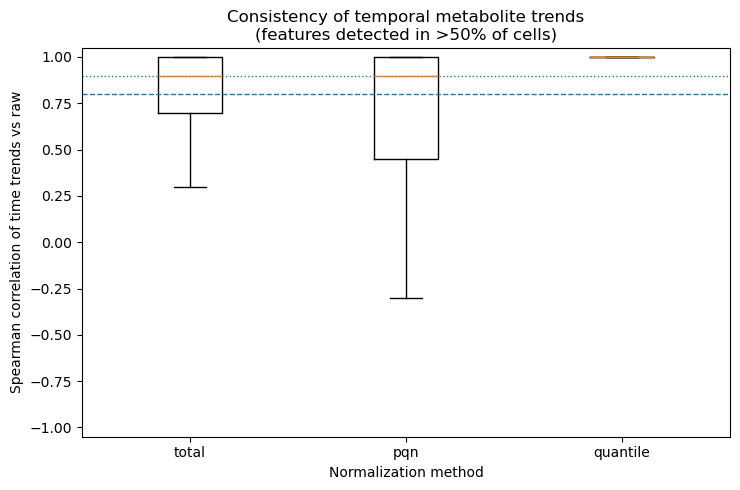

In [14]:

# ===== 13. 趋势一致性分布图 =====

fig, ax = plt.subplots(figsize=(7.5, 5))

data = [
    trend_consistency["total_trend_spearman"].dropna(),
    trend_consistency["pqn_trend_spearman"].dropna(),
    trend_consistency["quantile_trend_spearman"].dropna(),
]

ax.boxplot(data, tick_labels=["total", "pqn", "quantile"], showfliers=False)
ax.axhline(0.8, linestyle="--", linewidth=1)
ax.axhline(0.9, linestyle=":", linewidth=1)

ax.set_ylim(-1.05, 1.05)
ax.set_ylabel("Spearman correlation of time trends vs raw")
ax.set_xlabel("Normalization method")
ax.set_title(
    f"Consistency of temporal metabolite trends\n"
    f"(features detected in >{MIN_DETECTION_FRACTION:.0%} of cells)"
)
fig.tight_layout()
plt.show()


In [15]:

# ===== 14. 选择代表性高检出率代谢物并绘制趋势 =====

def choose_example_features(feature_names, qc, consistency, preferred=None, n=12):
    preferred = preferred or []
    selected = []

    # 1) 优先放用户指定 feature
    for f in preferred:
        if f in set(feature_names):
            selected.append(f)

    # 2) 其它特征按 detection fraction 高、且不同 normalization 下趋势总体稳定排序
    tmp = consistency.copy()
    tmp["mean_trend_spearman"] = tmp[
        ["total_trend_spearman", "pqn_trend_spearman", "quantile_trend_spearman"]
    ].mean(axis=1)
    tmp = tmp.sort_values(
        ["detection_fraction", "mean_trend_spearman"],
        ascending=False,
    )

    for f in tmp["feature"]:
        if f not in selected:
            selected.append(f)
        if len(selected) >= n:
            break

    return selected[:n]


example_features = choose_example_features(
    feature_names,
    feature_qc,
    trend_consistency,
    PREFERRED_FEATURES,
    N_TREND_EXAMPLES,
)

print("Example features:", example_features)


Example features: ['732.5770966', '736.6043594', '756.5759797', '757.5801869', '760.6072863', '734.5919668', '706.5608946', '759.5953865', '704.5458686', '758.5909089', '761.6114242', '708.575566']


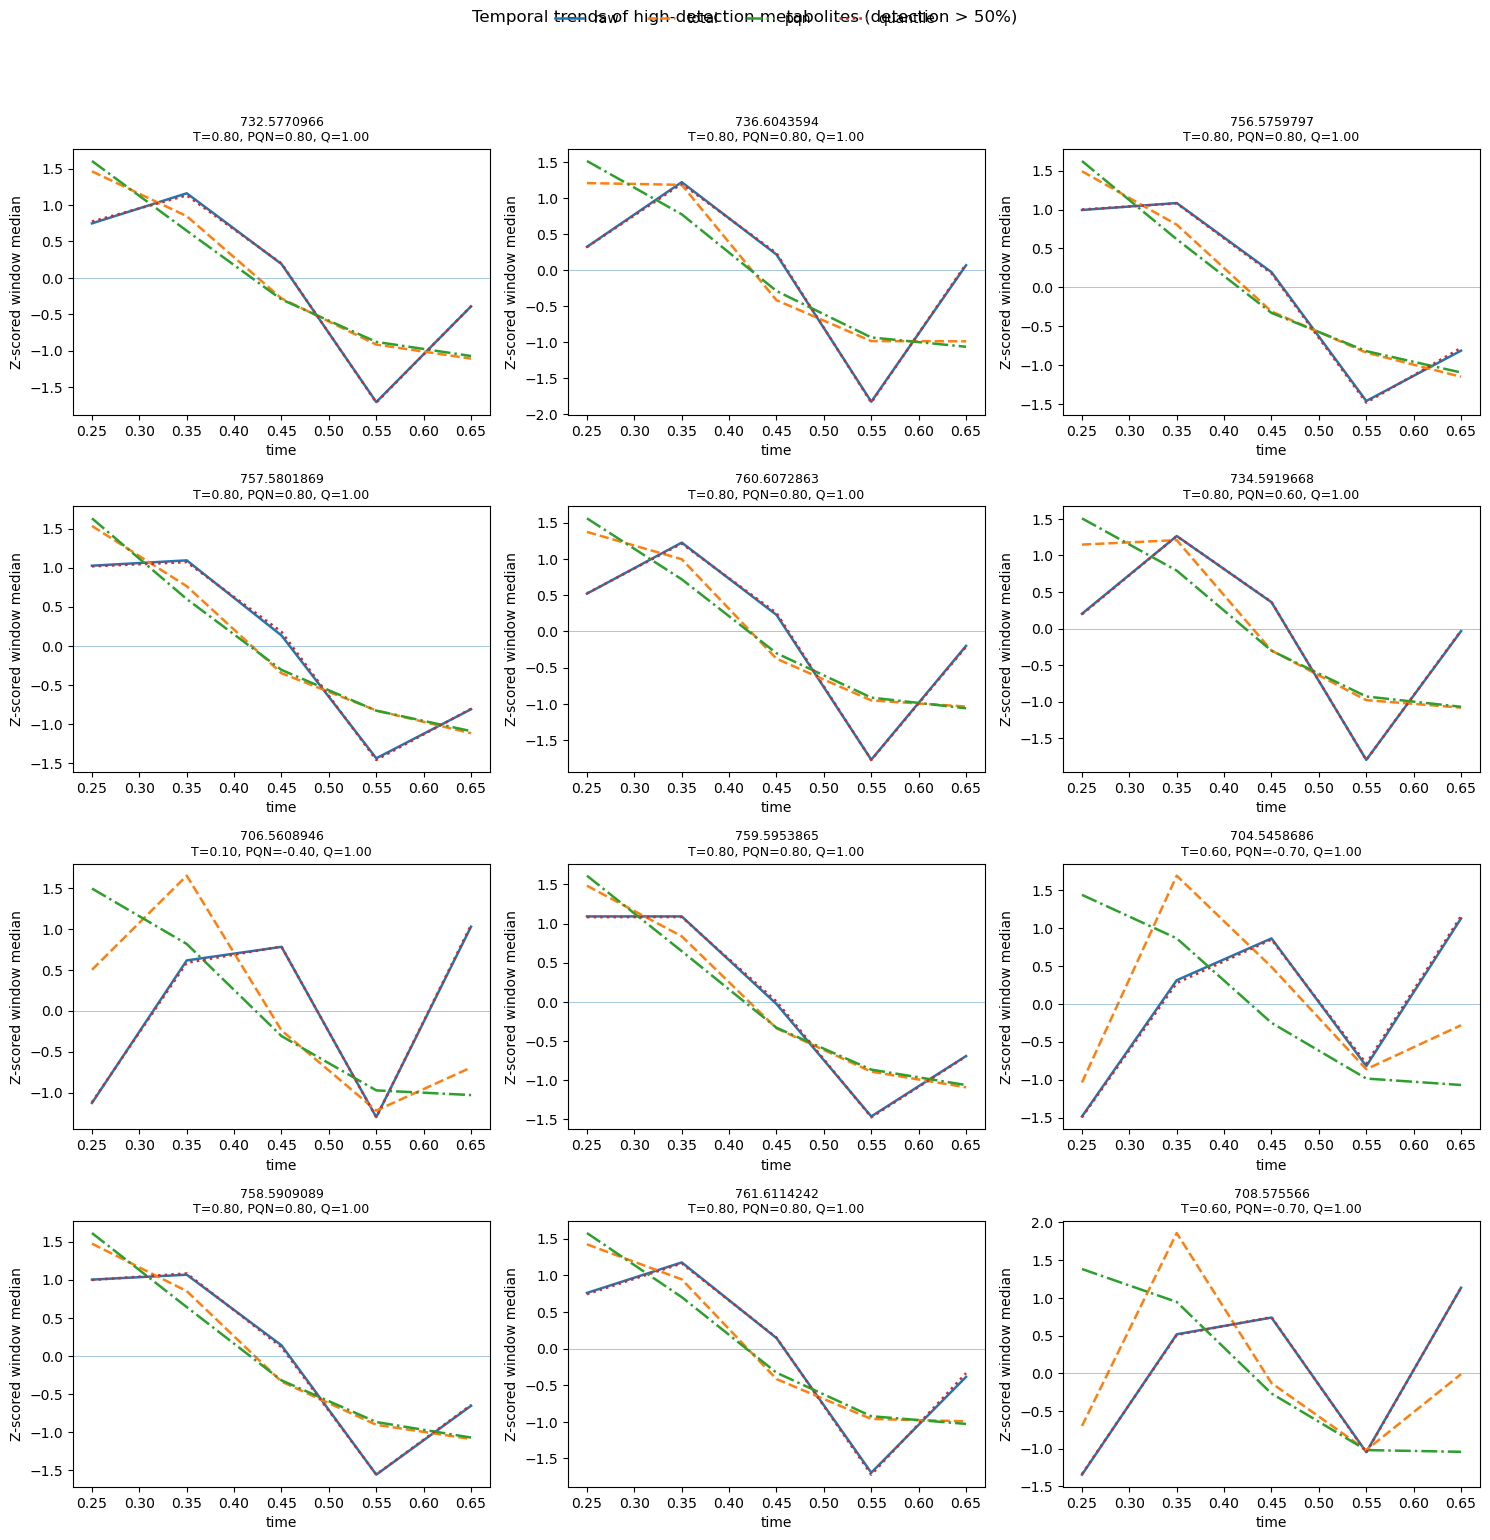

In [16]:

# ===== 15. 绘制代表性代谢物的 z-scored temporal trends =====

n = len(example_features)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.8*nrows), squeeze=False)

styles = {
    "raw": "-",
    "total": "--",
    "pqn": "-.",
    "quantile": ":",
}

for ax, feature in zip(axes.flat, example_features):
    j = np.where(feature_names == feature)[0][0]

    for method in ["raw", "total", "pqn", "quantile"]:
        ax.plot(
            window_centers,
            trend_z[method][:, j],
            linestyle=styles[method],
            linewidth=1.8,
            label=method,
        )

    row = trend_consistency.loc[trend_consistency["feature"] == feature].iloc[0]
    rho_txt = (
        f"T={row['total_trend_spearman']:.2f}, "
        f"PQN={row['pqn_trend_spearman']:.2f}, "
        f"Q={row['quantile_trend_spearman']:.2f}"
    )

    ax.set_title(f"{feature}\n{rho_txt}", fontsize=9)
    ax.set_xlabel(TIME_KEY)
    ax.set_ylabel("Z-scored window median")
    ax.axhline(0, linewidth=0.7, alpha=0.4)

for ax in axes.flat[len(example_features):]:
    ax.axis("off")

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)
fig.suptitle(
    f"Temporal trends of high-detection metabolites "
    f"(detection > {MIN_DETECTION_FRACTION:.0%})",
    y=1.01,
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


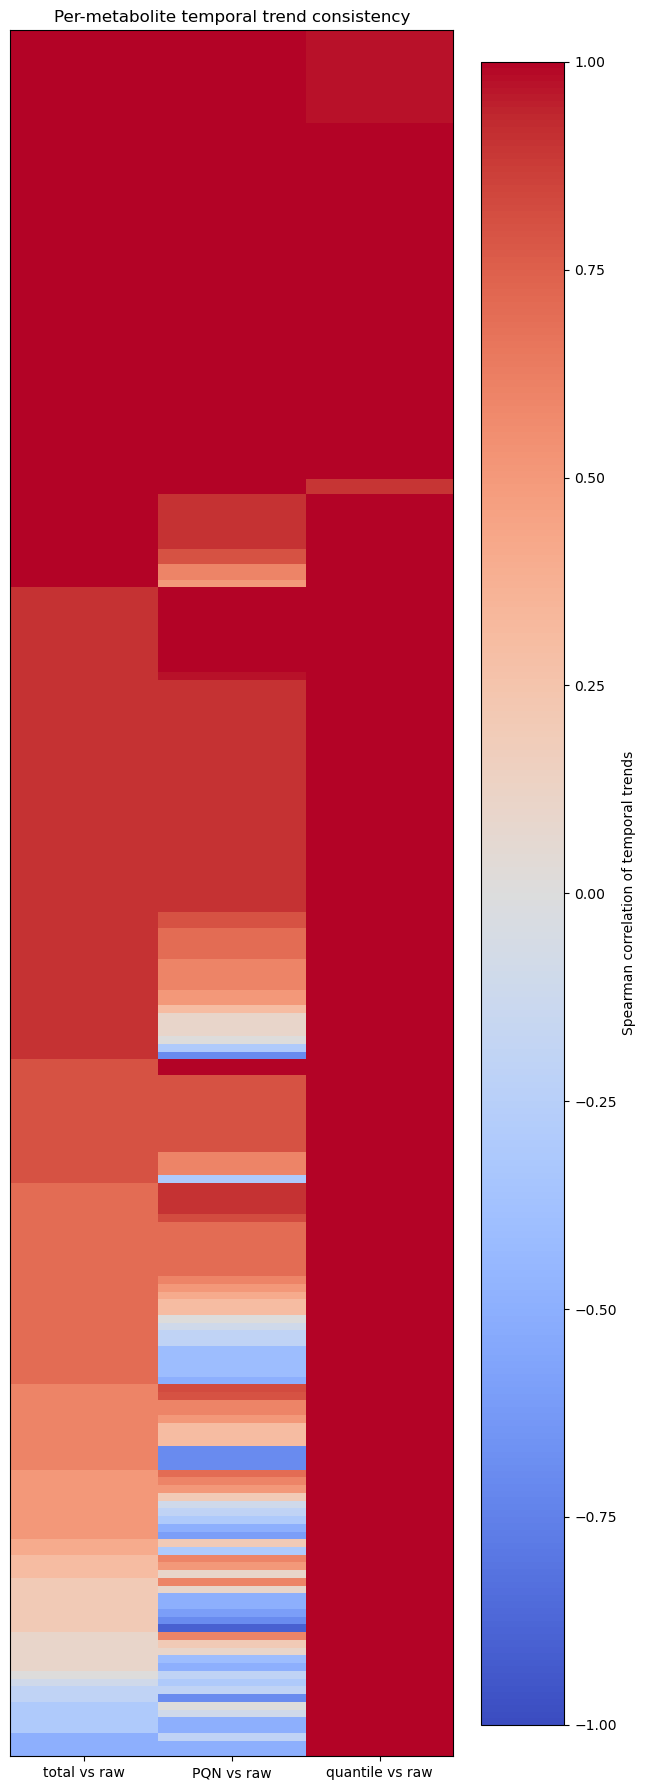

In [17]:

# ===== 16. 可选：把所有高检出率代谢物的趋势一致性画成 heatmap =====

trend_similarity_table = trend_consistency.set_index("feature")[
    [
        "total_trend_spearman",
        "pqn_trend_spearman",
        "quantile_trend_spearman",
    ]
].sort_values(
    ["total_trend_spearman", "pqn_trend_spearman", "quantile_trend_spearman"],
    ascending=False,
)

fig_height = max(5, min(18, 0.20 * len(trend_similarity_table)))
fig, ax = plt.subplots(figsize=(6.5, fig_height))

im = ax.imshow(
    trend_similarity_table.to_numpy(),
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    aspect="auto",
)

ax.set_xticks(range(3))
ax.set_xticklabels(["total vs raw", "PQN vs raw", "quantile vs raw"])

# 特征过多时不显示全部标签
if len(trend_similarity_table) <= 60:
    ax.set_yticks(range(len(trend_similarity_table)))
    ax.set_yticklabels(trend_similarity_table.index, fontsize=7)
else:
    ax.set_yticks([])

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Spearman correlation of temporal trends")
ax.set_title("Per-metabolite temporal trend consistency")
fig.tight_layout()
plt.show()


In [18]:

# ===== 17. 保存结果 =====

feature_qc.to_csv(
    OUTPUT_DIR / "high_detection_feature_qc.csv",
    index=False,
)

sim_pearson.to_csv(
    OUTPUT_DIR / "correlation_structure_similarity_pearson.csv"
)
sim_spearman.to_csv(
    OUTPUT_DIR / "correlation_structure_similarity_spearman.csv"
)

trend_consistency.to_csv(
    OUTPUT_DIR / "metabolite_temporal_trend_consistency.csv",
    index=False,
)

trend_summary.to_csv(
    OUTPUT_DIR / "metabolite_temporal_trend_consistency_summary.csv",
    index=False,
)

# 保存各方法的滑动窗口趋势
for method, T in trends.items():
    trend_df = pd.DataFrame(T, columns=feature_names)
    trend_df.insert(0, "window_center", window_centers)
    trend_df.to_csv(
        OUTPUT_DIR / f"temporal_trends_{method}.csv",
        index=False,
    )

metadata = {
    "methods": METHODS,
    "time_key": TIME_KEY,
    "min_detection_fraction": MIN_DETECTION_FRACTION,
    "window_width": WINDOW_WIDTH,
    "step_size": STEP_SIZE,
    "min_cells_per_window": MIN_CELLS_PER_WINDOW,
    "trend_statistic": TREND_STATISTIC,
    "correlation_method": CORR_METHOD,
    "n_cells": int(len(time)),
    "n_features_high_detection": int(len(feature_names)),
}

with open(
    OUTPUT_DIR / "normalization_consistency_metadata.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Results saved to:", OUTPUT_DIR.resolve())


Results saved to: /home/zby/scMM/data/algea_results/res/1mM



## 论文/回复审稿人的解释建议

这套分析刻意限制在**原始数据检出率 >50% 的代谢物**，以降低严重 dropout 对相关系数和时间趋势的影响。

建议重点报告两类结果：

1. **Correlation structure consistency**  
   若 raw、total、PQN 和 quantile 的 vectorized correlation matrices 之间保持较高 Spearman similarity，则说明主要 metabolite co-abundance pattern 并非由某一种 normalization 单独产生。

2. **Temporal trend consistency**  
   对每个高检出率代谢物分别比较 raw 与 total/PQN/quantile 下的滑动窗口趋势。由于四种方法的绝对尺度不同，先在每个方法内对趋势做 z-score，再比较趋势相关性。因此这里评价的是**时间变化的方向和形状是否稳定**，而不是不同 normalization 下数值是否完全相同。

可在 Supplementary 中优先展示：
- 4×4 correlation-structure similarity heatmap；
- raw vs total/PQN/quantile 的 metabolite-pair correlation scatter；
- temporal-trend consistency boxplot；
- 6–12 个代表性高检出率代谢物的四方法趋势叠加图。
